The objective of this notebook is to implement and explore a convolucional network for the first time. We will build a network used for number prediction, using images from MNIST.

In [1]:
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim


In [2]:
#If we have an accelerator, we use it. Otherwise, we will use our cpu
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps" # Para quem usa Mac M1/M2/M3
else:
    device = "cpu"

print(f"Using {device} device")

Using cpu device


# Setting the dataset 

In [3]:
training_Data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_Data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [4]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_Data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_Data, batch_size=64, shuffle=False)

# Defining the Class

In [5]:
class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            #All these parameters were used based on my study on https://cs231n.github.io/convolutional-networks/ and it recommendations
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1), #after this we have 28x28x16 (16 filters)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), #after this we have 14x14x16
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), #after this we have 14x14x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) #after this, we have 7x7x32
        )
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(1568, 128), # 1568 = 32 channels * 7 (height) * 7 (width)      128 is the number of neurons
            nn.ReLU(),
            nn.Linear(128, 10) # 10 outputs for the numbers 0, ... , 9
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        classification = self.classifier(x)
        return classification
    


# Optmizing the Network and Training Loop

In [6]:
model = ConvNeuralNetwork()
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [7]:
epochs = 5
for epoch in range(epochs):
    print(f'Epoch {epoch + 1}\n--------------------')
    for lote, (X, y) in enumerate(train_dataloader):
        prediction = model(X) #forward
        error = loss(prediction, y)
        #backpropagation
        optimizer.zero_grad()
        error.backward()
        optimizer.step()

        if lote % 100 == 0:
            print(f"Current error: {error.item():>7f}")



Epoch 1
--------------------
Current error: 2.314471
Current error: 0.602895
Current error: 0.340792
Current error: 0.106154
Current error: 0.219456
Current error: 0.091270
Current error: 0.046420
Current error: 0.029349
Current error: 0.118589
Current error: 0.124345
Epoch 2
--------------------
Current error: 0.114676
Current error: 0.137657
Current error: 0.054981
Current error: 0.062362
Current error: 0.042671
Current error: 0.086093
Current error: 0.027975
Current error: 0.071626
Current error: 0.139270
Current error: 0.045920
Epoch 3
--------------------
Current error: 0.026458
Current error: 0.023257
Current error: 0.079471
Current error: 0.010141
Current error: 0.068180
Current error: 0.003723
Current error: 0.032478
Current error: 0.082375
Current error: 0.072427
Current error: 0.110931
Epoch 4
--------------------
Current error: 0.026038
Current error: 0.015908
Current error: 0.009282
Current error: 0.006363
Current error: 0.005044
Current error: 0.036280
Current error: 0.049

# Testing our Model

In [8]:
def test_model(dataloader, model, loss):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() #to start the evaluation
    loss_test, hits = 0, 0
    with torch.no_grad():  #we do not need the gradient during the test, because we will not do any backpropagation
        for X, y in dataloader:
            prediction = model(X)
            loss_test += loss(prediction, y).item()
            hits += (prediction.argmax(1) == y).type(torch.float).sum().item()

    loss_test /= num_batches
    accuracy = hits / size
    print(f"Test results: \n Accuracy: {(100*accuracy):>0.1f}%, Average Loss: {loss_test:>8f} \n")

test_model(test_dataloader, model, loss)

Test results: 
 Accuracy: 99.0%, Average Loss: 0.030508 



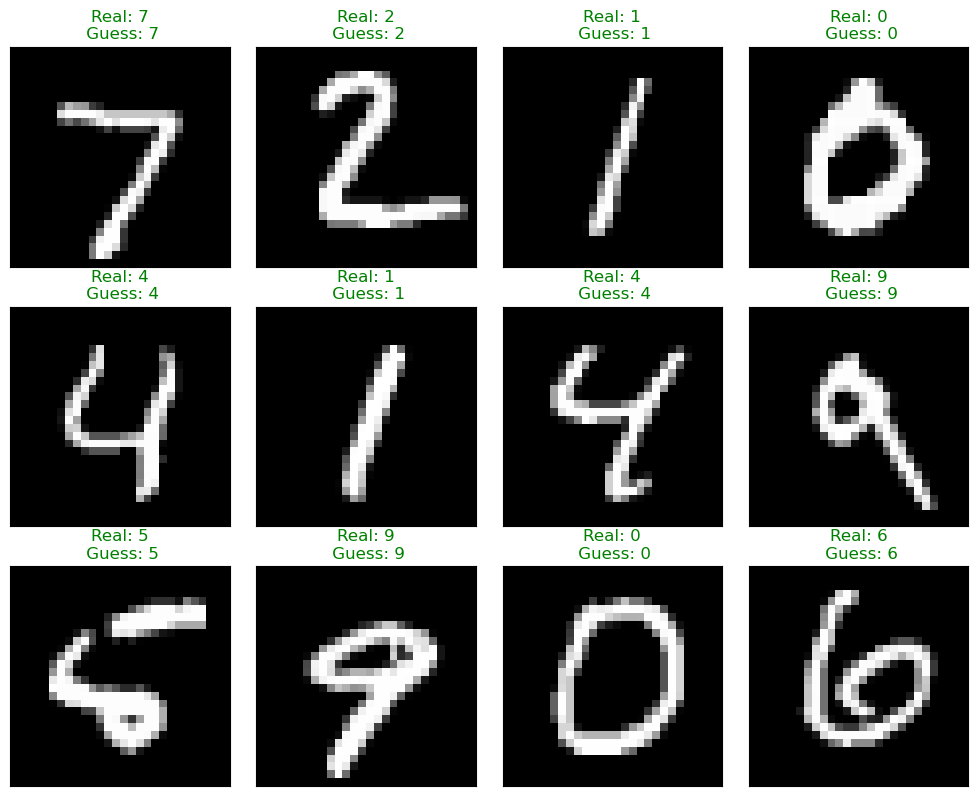

In [9]:
images, real_labels = next(iter(test_dataloader)) #selecting a image our model havent seen yet
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1) #select the index wit the biggest probability
fig = plt.figure(figsize=(10, 8))
for i in range(12):
    ax = fig.add_subplot(3, 4, i+1, xticks=[], yticks=[])
    img = images[i].squeeze()
    ax.imshow(img, cmap='gray')
    real = real_labels[i].item()
    guess = predictions[i].item()

    colour = 'green' if real == guess else 'red'
    ax.set_title(f"Real: {real}\n Guess: {guess}", color=colour)

plt.tight_layout()
plt.show()

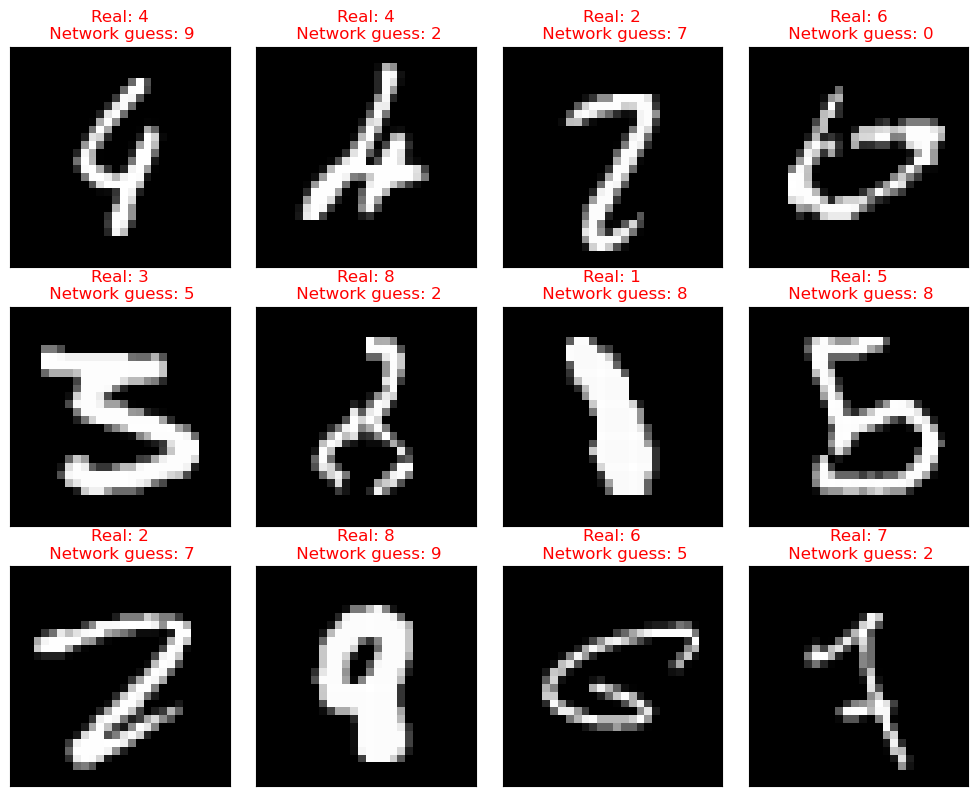

In [10]:
model.eval()

#Empty lists to put our errors
wrong_images = []
wrong_guesses = []
true_answers = []

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        
        #True here means our network guessed wrong
        mask_errors = (predictions != labels)
        index_errors = mask_errors.nonzero(as_tuple=True)[0]
        for idx in index_errors:
            wrong_images.append(images[idx])
            wrong_guesses.append(predictions[idx].item())
            true_answers.append(labels[idx].item())
            if len(wrong_images) == 12:
                break
                
        if len(wrong_images) == 12:
            break

fig = plt.figure(figsize=(10, 8))

for i in range(12):
    ax = fig.add_subplot(3, 4, i+1, xticks=[], yticks=[])
    img = wrong_images[i].squeeze() 
    
    ax.imshow(img, cmap='gray')
    
    # Todos os títulos serão vermelhos, pois filtramos apenas os erros
    ax.set_title(f"Real: {true_answers[i]}\n Network guess: {wrong_guesses[i]}", color="red")

plt.tight_layout()
plt.show()